# 1. Setup dell'Ambiente e Riproducibilità
Impostiamo i seed per:
* **Python (`os` e `random`):** Per le operazioni base e le strutture dati (hash).
* **NumPy:** Per la manipolazione numerica dei dati.
* **TensorFlow:** Fondamentale per l'inizializzazione deterministica dei pesi dei modelli.

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf 

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

print(f"Random seed set to: {SEED} (Python, NumPy, TensorFlow)")

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Random seed set to: 42 (Python, NumPy, TensorFlow)


# 2. Configurazione e Import Dati

In questa sezione impostiamo le basi del preprocessing:
* **Input/Output:** Definiamo dove sono i file grezzi (`INPUT_FILES`) e dove salveremo quelli processati (`processed_step1_final`).
* **Split Sizes:** Decidiamo che i primi **35.000 frame** serviranno per il *training* (e quindi per calcolare media e deviazione standard degli scaler), i successivi **10.000** per la validazione, e il resto per il test.

In [3]:
import os
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIGURATION
# =========================
INPUT_FILES = {
    "coords": "coordinates.csv",
    "forces": "forces.csv",
    "velo": "velocity.csv"
}
OUT_DIR = "processed_step1_final"
os.makedirs(OUT_DIR, exist_ok=True)

# Definiamo quanti dati usare per il fitting degli scaler (es. primi 70%)
TRAIN_SIZE = 35000
VAL_SIZE = 10000

# 3. Funzioni Ausiliarie (Helpers)

Definiamo tre funzioni critiche per la pipeline:

1.  **`read_dataset`**: Una funzione robusta per caricare i CSV. Gestisce automaticamente diversi separatori (`;`, `\t`, spazi) e pulisce eventuali virgolette, dato che i file scientifici hanno spesso formattazioni inconsistenti.
2.  **`get_kabsch_rotation_matrix`**: Implementa l'algoritmo di **Kabsch**. Calcola la matrice di rotazione ottimale per sovrapporre una struttura $P$ a una struttura target $Q$, minimizzando la distanza RMSD.
3.  **`save_subset`**: Gestisce la normalizzazione (Scaling) e il salvataggio.
    * *Global Scaling:* Usato per le coordinate per preservare la geometria 3D (unica media/std per tutti gli atomi).
    * *Standard Scaling:* Usato per Forze e Velocità (media/std calcolata colonna per colonna).

In [4]:
# =========================
# HELPER FUNCTIONS
# =========================
def read_dataset(path):
    """
    Reads the dataset handling different formats (semicolon, tab, whitespace).
    Returns dataframe and detected separator.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

    # 1. Try semicolon
    try:
        df = pd.read_csv(path, sep=";", header=None, engine="python")
        if df.shape[1] > 1: return df, ";"
    except: pass
    
    # 2. Read as text to clean quotes
    with open(path, 'r') as f:
        lines = f.readlines()
    cleaned_lines = [line.replace('"', '').strip() for line in lines]
    from io import StringIO
    cleaned_text = '\n'.join(cleaned_lines)
    
    # 3. Try tab
    df = pd.read_csv(StringIO(cleaned_text), sep="\t", header=None, engine="python")
    if df.shape[1] > 1: return df, "\\t (cleaned)"
    
    # 4. Fallback to whitespace
    df = pd.read_csv(StringIO(cleaned_text), sep=r"\s+", header=None, engine="python")
    return df, "whitespace (cleaned)"

def get_kabsch_rotation_matrix(P, Q):
    """
    Calculates the optimal rotation matrix R to align P to Q.
    P, Q: (N_atoms, 3) centered coordinates.
    Returns: R (3, 3) such that P @ R ~= Q
    """
    # Compute covariance matrix
    H = P.T @ Q
    
    # SVD
    U, S, Vt = np.linalg.svd(H)
    
    # Optimal rotation
    R = Vt.T @ U.T
    
    # Handle reflection case (ensure right-handed system)
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
        
    return R

def save_subset(data, name, scaler_mode, out_dir):
    """
    Helper to save scaled subsets.
    scaler_mode: 'global' (unified mean/std for all atoms) or 'standard' (per-feature).
    """
    # Split
    train = data[:TRAIN_SIZE]
    val = data[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
    test = data[TRAIN_SIZE + VAL_SIZE:]
    
    # === SCALING LOGIC ===
    if scaler_mode == 'global':
        # Global Scaling (Best for Coordinates to preserve geometry)
        # We calculate ONE mean and ONE std for the entire training matrix
        mean_val = train.mean()
        std_val = train.std()
        
        scaler_params = {'mean': float(mean_val), 'std': float(std_val), 'type': 'global'}
        joblib.dump(scaler_params, os.path.join(out_dir, f"scaler_{name}.pkl"))
        
        # Apply transformation manually
        def transform_global(arr, m, s): return (arr - m) / s
        
        train_s = transform_global(train, mean_val, std_val)
        val_s   = transform_global(val, mean_val, std_val)
        test_s  = transform_global(test, mean_val, std_val)
        full_s  = transform_global(data, mean_val, std_val)
        
    else:
        # Standard Scaling (Best for Forces/Velocities)
        # Calculates mean/std for EACH column independently
        scaler = StandardScaler()
        scaler.fit(train)
        joblib.dump(scaler, os.path.join(out_dir, f"scaler_{name}.pkl"))
        
        train_s = scaler.transform(train)
        val_s = scaler.transform(val)
        test_s = scaler.transform(test)
        full_s = scaler.transform(data)
    
    # Save CSVs
    cols = [f"f{i}" for i in range(data.shape[1])]
    pd.DataFrame(full_s, columns=cols).to_csv(os.path.join(out_dir, f"{name}_scaled.csv"), index=False)
    # pd.DataFrame(data, columns=cols).to_csv(os.path.join(out_dir, f"{name}_clean.csv"), index=False) # Optional: Save raw aligned
    
    # Return stats (CAST TO NATIVE PYTHON FLOAT for JSON serialization check)
    return {
        "train_mean": float(train_s.mean()), "train_std": float(train_s.std()),
        "val_mean":   float(val_s.mean()),   "val_std":   float(val_s.std()),
        "test_mean":  float(test_s.mean()),  "test_std":  float(test_s.std()),
        "scaling_mode": scaler_mode
    }

# 4. Pipeline Principale: Allineamento e Rotazione Vettoriale

Questa funzione orchestra l'intero processo di preprocessing. Ecco i passaggi chiave che esegue:

1.  **Reshaping 3D:** Converte i dati da tabelle piatte a tensori `(Frames, Atomi, 3)` per poter fare calcoli geometrici.
2.  **Ciclo di Allineamento (Alignment Loop):**
    * Centra la proteina nell'origine (rimuove la traslazione).
    * Calcola la matrice di rotazione $R$ rispetto al primo frame (Kabsch).
    * Ruota le **Coordinate**.
    * **CRUCIALE:** Applica la *stessa* rotazione $R$ anche ai vettori **Forze** e **Velocità**. Se ruotiamo la molecola, anche la forza che agisce su un atomo deve ruotare di conseguenza!
3.  **Verifica RMSD:** Calcola quanto la proteina è "stabile" dopo l'allineamento. Un RMSD basso (es. 0.35) indica che l'allineamento ha funzionato bene e ha rimosso i movimenti globali.

In [5]:
# =========================
# MAIN PIPELINE
# =========================
def run_physics_consistent_pipeline():
    print("="*80)
    print("PHYSICS-CONSISTENT PREPROCESSING PIPELINE (FINAL)")
    print("Actions: COM Removal -> Kabsch Rotation -> Vector Rotation -> Hybrid Scaling")
    print("="*80)

    # 1. LOAD ALL DATA
    print("\n1. Loading Datasets...")
    dfs = {}
    time_col = None
    
    for key, path in INPUT_FILES.items():
        print(f"   Loading {key} from {path}...")
        df, sep = read_dataset(path)
        # Convert to numpy float32, skipping time column (col 0)
        dfs[key] = df.iloc[:, 1:].values.astype(np.float32)
        if key == "coords":
            time_col = df.iloc[:, 0].values # Save time from coords
            
    # Check shapes
    n_frames, n_features = dfs["coords"].shape
    n_atoms = n_features // 3
    print(f"   Frames: {n_frames}, Atoms: {n_atoms}")
    
    if dfs["forces"].shape != dfs["coords"].shape:
        raise ValueError("Shape mismatch between Coords and Forces!")

    # Reshape to 3D (Frames, Atoms, 3)
    X = dfs["coords"].reshape(n_frames, n_atoms, 3)
    F = dfs["forces"].reshape(n_frames, n_atoms, 3)
    V = dfs["velo"].reshape(n_frames, n_atoms, 3)

    # 2. ALIGNMENT LOOP
    print("\n2. Aligning Trajectory (Calculating R on X, applying to F and V)...")
    
    X_aligned = np.zeros_like(X)
    F_aligned = np.zeros_like(F)
    V_aligned = np.zeros_like(V)
    
    # Reference: Frame 0, centered
    ref_X = X[0] - X[0].mean(axis=0)
    
    for t in range(n_frames):
        # A. Center Coordinates (Remove Translation)
        center_t = X[t].mean(axis=0)
        X_centered = X[t] - center_t
        
        # B. Calculate Rotation Matrix R
        if t == 0:
            R = np.eye(3)
        else:
            R = get_kabsch_rotation_matrix(X_centered, ref_X)
        
        # C. Apply Rotations
        # Coords: Rotate the centered coordinates
        X_aligned[t] = X_centered @ R
        
        # VECTORS (Forces/Vel): Rotate ONLY (Vectors have no position, so no centering)
        # We apply the same R so they point in the correct direction relative to X_aligned
        F_aligned[t] = F[t] @ R
        V_aligned[t] = V[t] @ R
        
        if t % 10000 == 0: print(f"   Processed frame {t}/{n_frames}")

    # Check RMSD improvement
    rmsd_raw = np.sqrt(np.mean((X - X[0])**2))
    rmsd_aln = np.sqrt(np.mean((X_aligned - ref_X)**2))
    print(f"   RMSD before: {rmsd_raw:.2f} -> RMSD after: {rmsd_aln:.2f}")

    # 3. FLATTEN & SAVE ARTIFACTS
    print("\n3. Flattening and Saving...")
    
    # Flatten back to (Frames, Features)
    data_map = {
        "coordinates": X_aligned.reshape(n_frames, -1),
        "forces":      F_aligned.reshape(n_frames, -1),
        "velocity":    V_aligned.reshape(n_frames, -1)
    }
    
    stats_summary = {}
    
    for name, data in data_map.items():
        # HYBRID SCALING STRATEGY:
        # - Coordinates: 'global' (Preserves 3D geometry shape)
        # - Forces/Vels: 'standard' (Normalizes each vector component independently)
        mode = 'global' if name == 'coordinates' else 'standard'
        print(f"   Processing {name} with mode='{mode}'...")
        
        stats = save_subset(data, name, mode, OUT_DIR)
        stats_summary[name] = stats
        
    # Save Time and Reference
    if time_col is not None:
        pd.Series(time_col).to_csv(os.path.join(OUT_DIR, "time.csv"), index=False, header=False)
        
    np.save(os.path.join(OUT_DIR, "reference_frame_centered.npy"), ref_X)
    
    # Save Meta
    meta = {
        "n_atoms": int(n_atoms),
        "alignment": "Kabsch (Centered)",
        "vector_rotation": True,
        "split": {"train": TRAIN_SIZE, "val": VAL_SIZE},
        "stats": stats_summary
    }
    with open(os.path.join(OUT_DIR, "pipeline_metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return stats_summary

# 5. Esecuzione della Pipeline

Lanciamo il processo. Ci aspettiamo che l'RMSD (Root Mean Square Deviation) scenda drasticamente, indicando che abbiamo rimosso i movimenti casuali di rotazione e traslazione.
Alla fine verrà stampata una tabella riassuntiva delle deviazioni standard post-scaling (dovrebbero essere vicine a 1.0 per train).

In [6]:
# =========================
# RUN
# =========================
if __name__ == "__main__":
    stats = run_physics_consistent_pipeline()
    
    print("\n" + "="*80)
    print(f"{'Dataset':<15} {'Mode':<10} {'Train Std':>10} {'Val Std':>10} {'Test Std':>10}")
    print("-" * 65)
    for name, s in stats.items():
        print(f"{name:<15} {s['scaling_mode']:<10} {s['train_std']:>10.4f} {s['val_std']:>10.4f} {s['test_std']:>10.4f}")
    print("="*80)
    print(f"Done. Files saved to {OUT_DIR}/")

PHYSICS-CONSISTENT PREPROCESSING PIPELINE (FINAL)
Actions: COM Removal -> Kabsch Rotation -> Vector Rotation -> Hybrid Scaling

1. Loading Datasets...
   Loading coords from coordinates.csv...
   Loading forces from forces.csv...
   Loading velo from velocity.csv...
   Frames: 50001, Atoms: 138

2. Aligning Trajectory (Calculating R on X, applying to F and V)...
   Processed frame 0/50001
   Processed frame 10000/50001
   Processed frame 20000/50001
   Processed frame 30000/50001
   Processed frame 40000/50001
   Processed frame 50000/50001
   RMSD before: 14.78 -> RMSD after: 0.35

3. Flattening and Saving...
   Processing coordinates with mode='global'...
   Processing forces with mode='standard'...
   Processing velocity with mode='standard'...

Dataset         Mode        Train Std    Val Std   Test Std
-----------------------------------------------------------------
coordinates     global         1.0000     0.9491     0.9823
forces          standard       1.0000     1.0742     1.

# 1. Caricamento e Preparazione Dati (Triple-Head Input)

In questa fase carichiamo i dataset processati. L'Autoencoder ha un compito complesso: deve imparare a comprimere e ricostruire tre grandezze fisiche diverse simultaneamente.

* **Input Combinato:** L'encoder riceve tutto insieme (Coordinate + Velocità + Forze).
* **Target Split:** Definiamo una funzione helper `split_targets` per separare l'output in tre parti, necessarie per calcolare l'errore su ogni "testa" del decoder separatamente.

In [7]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_PATH = "processed_step1_final" 
OUT_PATH = "processed_step2_triple_head"
MODEL_PATH = "saved_models_triple"

os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

# Parameters
BATCH_SIZE = 128      
MAX_EPOCHS = 100
PATIENCE = 15
LATENT_DIM = 128      # Dimensione dello Spazio Latente (compresso)

print("=" * 70)
print("TRAINING TRIPLE-HEAD AUTOENCODER (PHYSICS INFORMED)")
print("=" * 70)

# ================= 1. LOAD DATA =================
print(f"Loading Data from {INPUT_PATH}...")

# 1. Load Scaled Data generated by Step 1
df_coords = pd.read_csv(os.path.join(INPUT_PATH, "coordinates_scaled.csv"))
df_velo = pd.read_csv(os.path.join(INPUT_PATH, "velocity_scaled.csv"))
df_forces = pd.read_csv(os.path.join(INPUT_PATH, "forces_scaled.csv"))

vals_coords = df_coords.values.astype(np.float32)
vals_velo = df_velo.values.astype(np.float32)
vals_forces = df_forces.values.astype(np.float32)

N_FEATS = vals_coords.shape[1] # Features per branch (es. 414)
print(f"Features per physical quantity: {N_FEATS}")

# 2. Concatenate for Splitting (Input is concatenation of all)
# Shape: [N_frames, (Coords + Velo + Forces)]
data_all = np.concatenate([vals_coords, vals_velo, vals_forces], axis=1)
INPUT_DIM = data_all.shape[1]
print(f"Total Input Dimension: {INPUT_DIM} (Should be {N_FEATS} * 3)")

# 3. Random Split (Shuffle is ON for Autoencoder training to learn global manifold)
indices = np.arange(len(data_all))

X_train_val, X_test, idx_train_val, idx_test = train_test_split(
    data_all, indices, test_size=0.1, random_state=SEED, shuffle=True
)
X_train, X_val, idx_train, idx_val = train_test_split(
    X_train_val, idx_train_val, test_size=0.11, random_state=SEED, shuffle=True
)

# 4. Helper to separate targets for the 3 heads
def split_targets(X):
    # X columns: [0...N] -> Coords, [N...2N] -> Velo, [2N...3N] -> Forces
    c = X[:, :N_FEATS]
    v = X[:, N_FEATS : 2*N_FEATS]
    f = X[:, 2*N_FEATS :]
    return X, {"out_coords": c, "out_velo": v, "out_forces": f}

X_train_in, y_train = split_targets(X_train)
X_val_in, y_val = split_targets(X_val)
X_test_in, y_test = split_targets(X_test)

print(f"Train samples: {len(X_train_in)}")
print(f"Val samples:   {len(X_val_in)}")

TRAINING TRIPLE-HEAD AUTOENCODER (PHYSICS INFORMED)
Loading Data from processed_step1_final...
Features per physical quantity: 414
Total Input Dimension: 1242 (Should be 414 * 3)
Train samples: 40050
Val samples:   4950


# 2. Architettura Triple-Head Autoencoder

Definiamo qui la struttura della rete neurale:
1.  **Encoder Condiviso:** Comprime tutte le informazioni in un vettore latente di dimensione 128. Usa attivazioni *Swish* che performano meglio su dati fisici continui rispetto alla ReLU.
2.  **Tre Decoder Indipendenti:**
    * *Coords Decoder:* Ricostruisce la geometria.
    * *Velocity Decoder:* Ricostruisce il momento (Pesato x50 nella loss).
    * *Forces Decoder:* Ricostruisce le interazioni dinamiche (Pesato x20).

In [8]:
# ================= 2. BUILD TRIPLE-HEAD AUTOENCODER (VERSIONE 2.0 - STABILIZED) =================
def build_triple_head_ae(input_dim, single_dim, latent_dim):
    # Regolarizzazione: manteniamo bassa per non soffocare il modello
    reg = regularizers.l2(1e-7) 
    
    # ======================
    # 1. ENCODER (Shared)
    # ======================
    enc_input = layers.Input(shape=(input_dim,), name="input_combined")
    
    # Primo blocco massiccio per incrociare le feature (Coord+Velo+Forze)
    x = layers.Dense(1024, kernel_regularizer=reg)(enc_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    
    x = layers.Dense(512, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    
    # --- IL FIX CRUCIALE: LATENT SPACE NORMALIZZATO ---
    # Prima: Usciva un numero a caso (Linear).
    # Adesso: Calcoliamo il denso, MA LO NORMALIZZIAMO SUBITO.
    z = layers.Dense(latent_dim, activation="linear", name="z_dense")(x)
    latent = layers.BatchNormalization(name="latent_space")(z) 
    # Ora 'latent' avrà sempre media ~0 e std ~1. Perfetto per la LSTM futura.

    # ======================
    # 2. DECODERS (Heads)
    # ======================
    
    # --- HEAD 1: COORDINATES (Geometry) ---
    # Le coordinate sono semplici, bastano 2 layer
    d_c = layers.Dense(256, kernel_regularizer=reg)(latent)
    d_c = layers.BatchNormalization()(d_c)
    d_c = layers.Activation("swish")(d_c)
    
    d_c = layers.Dense(512, kernel_regularizer=reg)(d_c)
    d_c = layers.BatchNormalization()(d_c)
    d_c = layers.Activation("swish")(d_c)
    
    out_coords = layers.Dense(single_dim, activation="linear", name="out_coords")(d_c)
    
    # --- HEAD 2: VELOCITY (Momentum) - POTENZIATO ---
    # Aggiunto un layer extra (256) per raffinare la predizione
    d_v = layers.Dense(256, kernel_regularizer=reg)(latent) 
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)

    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v)
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)
    
    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v) # Layer extra rispetto a prima
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)
    
    out_velo = layers.Dense(single_dim, activation="linear", name="out_velo")(d_v)
    
    # --- HEAD 3: FORCES (Dynamics) - SUPER POTENZIATO ---
    # Le forze sono le più difficili (MSE 0.72). Diamogli più potenza profonda.
    d_f = layers.Dense(256, kernel_regularizer=reg)(latent) 
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)
    
    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f)
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)

    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f) # Layer extra
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)
    
    out_forces = layers.Dense(single_dim, activation="linear", name="out_forces")(d_f)
    
    # ======================
    # 3. ASSEMBLY
    # ======================
    model = models.Model(inputs=enc_input, outputs=[out_coords, out_velo, out_forces], name="triple_ae_v2")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss={
            "out_coords": "mse", 
            "out_velo": "mse", 
            "out_forces": "mse"
        },
        loss_weights={
            "out_coords": 1.0,  
            "out_velo": 50.0,   # Priorità alta
            "out_forces": 20.0  # Priorità alta
        }
    )
    
    encoder = models.Model(enc_input, latent)
    return model, encoder

# Istanziazione del nuovo modello
model, encoder = build_triple_head_ae(INPUT_DIM, N_FEATS, LATENT_DIM)
model.summary()

Model: "triple_ae_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_combined      │ (None, 1242)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │  1,272,832 │ input_combined[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    524,800 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_dense (Dense)     │ (None, 128)       │     65,664 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 128)       │        512 │ z_dense[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     33,024 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     33,024 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    131,584 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    131,584 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,539,546 (13.50 MB)

 Trainable params: 3,529,562 (13.46 MB)

 Non-trainable params: 9,984 (39.00 KB)

# 3. Addestramento del Modello

Avviamo il processo di training con due callback fondamentali:
1.  **EarlyStopping:** Ferma il training se la `val_loss` non migliora per 15 epoche, prevenendo l'overfitting inutile.
2.  **ReduceLROnPlateau:** Se il miglioramento stalla, dimezza il learning rate per cercare minimi più precisi nella loss function.

In [9]:
# ================= 3. TRAINING =================
callbacks_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

print("\nStarting Training...")
history = model.fit(
    X_train_in, y_train,
    validation_data=(X_val_in, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)


Starting Training...
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 67.1743 - out_coords_loss: 0.1242 - out_forces_loss: 0.9654 - out_velo_loss: 0.9548 - val_loss: 61.2526 - val_out_coords_loss: 0.0852 - val_out_forces_loss: 0.8733 - val_out_velo_loss: 0.8740 - learning_rate: 5.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 56.6907 - out_coords_loss: 0.0604 - out_forces_loss: 0.8165 - out_velo_loss: 0.8060 - val_loss: 55.2406 - val_out_coords_loss: 0.0641 - val_out_forces_loss: 0.8032 - val_out_velo_loss: 0.7823 - learning_rate: 5.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 52.5945 - out_coords_loss: 0.0591 - out_forces_loss: 0.7737 - out_velo_loss: 0.7412 - val_loss: 52.7803 - val_out_coords_loss: 0.0563 - val_out_forces_loss: 0.7798 - val_out_velo_loss: 0.7426 - learning_rate: 5.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 50.5789 - out_coords_loss: 0.0567 - out_forces_loss: 0.7571 - out_

# 4. Valutazione e Visualizzazione

Calcoliamo le metriche finali sul set di Test (dati mai visti).
Visualizziamo tre grafici:
1.  **Loss Totale:** L'andamento complessivo.
2.  **Component MSE:** L'errore specifico per ogni grandezza (Coords, Velo, Force).
3.  **Forces Check:** Un focus sulle forze, che sono spesso la parte più rumorosa.


--- FINAL EVALUATION ---
Total Weighted Loss: 42.7295
Coords MSE (Raw):    0.0150
Velocity MSE (Raw):  0.5739
Forces MSE (Raw):    0.7006


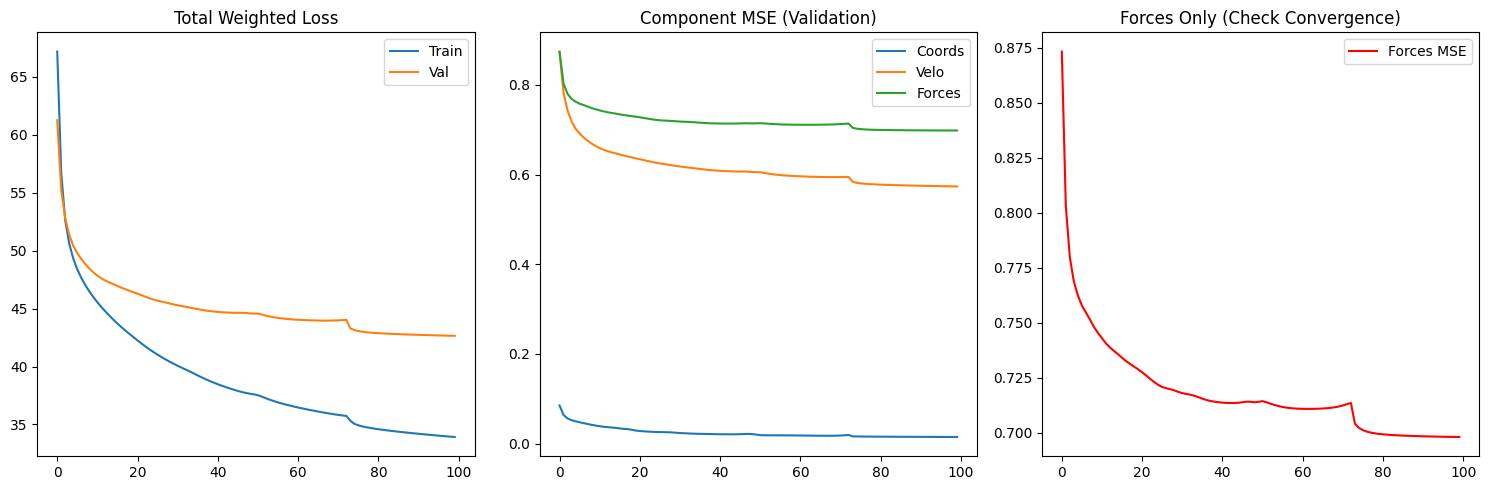

In [10]:
# ================= 4. EVALUATION =================
print("\n--- FINAL EVALUATION ---")
# evaluate returns: [loss_total, loss_c, loss_v, loss_f]
res = model.evaluate(X_test_in, y_test, verbose=0)

print(f"Total Weighted Loss: {res[0]:.4f}")
print(f"Coords MSE (Raw):    {res[1]:.4f}")
print(f"Velocity MSE (Raw):  {res[2]:.4f}")
print(f"Forces MSE (Raw):    {res[3]:.4f}")

# Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Total Weighted Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['val_out_coords_loss'], label='Coords')
plt.plot(history.history['val_out_velo_loss'], label='Velo')
plt.plot(history.history['val_out_forces_loss'], label='Forces')
plt.title('Component MSE (Validation)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['val_out_forces_loss'], label='Forces MSE', color='red')
plt.title('Forces Only (Check Convergence)')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "training_history_triple.png"))
plt.show()

# 5. Generazione Dataset Latente

Ora usiamo l'**Encoder** (la prima metà della rete) per trasformare tutto il dataset originale (414 features) nel nuovo formato compresso (128 features).
Questi file (`train_dataset.csv`, etc.) saranno l'input per il prossimo step (Time Series Forecasting).

In [11]:
# ================= 5. SAVE LATENT SPACE (ORDERED) =================
print("\nGenerating Ordered Latent Space for Temporal Learning...")

# Re-predict full ordered data for Step 3
# We need strictly temporal order: Frame 0 -> Frame 50000
X_full_in, _ = split_targets(data_all)
latent_full = encoder.predict(X_full_in, verbose=0)

cols = [f"Latent_{i}" for i in range(LATENT_DIM)]
df_latent = pd.DataFrame(latent_full, columns=cols)

# Using the split sizes from Step 1 config to keep consistency
# Train: 0 -> 35000 | Val: 35000 -> 45000 | Test: 45000 -> End
TRAIN_CUT = 35000
VAL_CUT = 35000 + 10000  # 45000

df_latent.iloc[:TRAIN_CUT].to_csv(os.path.join(OUT_PATH, "train_dataset.csv"), index=False)
df_latent.iloc[TRAIN_CUT:VAL_CUT].to_csv(os.path.join(OUT_PATH, "val_dataset.csv"), index=False)
df_latent.iloc[VAL_CUT:].to_csv(os.path.join(OUT_PATH, "test_dataset.csv"), index=False)

# Save Models
model.save(os.path.join(MODEL_PATH, "triple_ae.keras"))
encoder.save(os.path.join(MODEL_PATH, "triple_encoder.keras"))
print(f"✓ All done. Latent datasets saved in {OUT_PATH}")


Generating Ordered Latent Space for Temporal Learning...
✓ All done. Latent datasets saved in processed_step2_triple_head
